# Assignment 4: Customer Segmentation with Clustering

**Student Name:** Drake DelValle

---

## Assignment Overview

You've been hired as a data science consultant by a UK-based online gift retailer. They're spending the same amount on marketing to all customers regardless of value. Your task: segment their customer base using transaction data from 2009-2011, identify distinct customer groups, and provide actionable recommendations for each segment.

---

## Step 1: Import Libraries and Load Data

In [1]:
pip install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [9]:
# Load the Online Retail II dataset
# TODO: Load online_retail_II.csv from the data folder
df = pd.read_csv('data/online_retail_II.csv')  # Replace with pd.read_csv()

# Display basic information
# TODO: Display the first few rows and basic info about the dataset

df.info()

print("\n" + "="*80)
print(f"Data head:")
print(df.head())

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Dataset shape: {df.shape if df is not None else 'Not loaded'}")
print(f"Date range: [Check InvoiceDate column]")
print("="*80)

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB

Data head:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY C

---
## Step 2: Aggregate Transaction Data to Customer-Level RFM Features

### Clean Transaction Data

Before aggregating to customer-level, clean the transaction data:
- Remove rows with missing Customer ID
- Remove returns (negative Quantity)
- Create TotalSpend column (Quantity × Price)
- Convert InvoiceDate to datetime

In [12]:
# Clean the data
# TODO: Remove missing Customer IDs

df = df.dropna(subset=['Customer ID'])

# TODO: Remove negative quantities (returns)

df = df[df['Quantity'] >= 0]

# TODO: Create TotalSpend column

df['TotalSpend'] = df['Quantity'] * df['Price']

# TODO: Convert InvoiceDate to datetime

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


df.info()

print("\n" + "="*80)
print(f"Data head:")
print(df.head())

print("\n" + "="*80)
print("CHECKPOINT: After data cleaning")
print(f"Remaining transactions: {len(df) if df is not None else 'N/A'}")
print(f"Unique customers: {df['Customer ID'].nunique() if df is not None else 'N/A'}")
print("="*80)

<class 'pandas.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  str           
 1   StockCode    805620 non-null  str           
 2   Description  805620 non-null  str           
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[us]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  float64       
 7   Country      805620 non-null  str           
 8   TotalSpend   805620 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 61.5 MB

Data head:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHT

### Calculate RFM Features for Each Customer

Create three features for each customer:
- **Recency**: Days since last purchase (use December 10, 2011 as reference date)
- **Frequency**: Total number of unique invoices
- **Monetary**: Total amount spent

In [38]:
# Set reference date for recency calculation
reference_date = pd.to_datetime('2011-12-10')

# TODO: For each Customer ID, calculate:
# - Recency: (reference_date - max(InvoiceDate)).days

df['Recency'] = df.groupby('Customer ID')['InvoiceDate'].apply(lambda x: (reference_date - x.max()).days).copy()

print("Recency distribution:")
print(df['Recency'].value_counts().sort_index())

# - Frequency: count of unique Invoice numbers
df['Frequency'] = df.groupby('Customer ID')['Invoice'].transform('nunique')

print("Frequency distribution:")
print(df['Frequency'].value_counts().sort_index())

# - Monetary: sum of TotalSpend
df['Monetary'] = df.groupby('Customer ID')['TotalSpend'].transform('sum')

print("\nMonetary statistics:")
print(df['Monetary'].describe())

rfm_df = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalSpend': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=False)

print("\n" + "="*80)
print("CHECKPOINT: RFM Features Created")
if rfm_df is not None:
    print(f"Number of customers: {len(rfm_df)}")
    print(f"\nRFM Summary Statistics:")
    print(rfm_df.describe())
print("="*80)

Recency distribution:
Recency
0.0      28
1.0      82
2.0      70
3.0      76
4.0      69
         ..
733.0     4
735.0     3
736.0     5
737.0     6
738.0     4
Name: count, Length: 582, dtype: int64
Frequency distribution:
Frequency
1      35473
2      40295
3      45171
4      41874
5      41726
       ...  
203     3363
208     4434
211    12890
337     7230
398    11247
Name: count, Length: 90, dtype: int64

Monetary statistics:
count    805620.000000
mean      20942.533969
std       61689.538350
min           0.000000
25%        1783.680000
50%        4546.540000
75%       11650.850000
max      608821.650000
Name: Monetary, dtype: float64

CHECKPOINT: RFM Features Created
Number of customers: 5881

RFM Summary Statistics:
           Recency    Frequency       Monetary
count  5881.000000  5881.000000    5881.000000
mean    200.992858     6.287196    3017.076888
std     209.489651    13.012879   14734.128619
min       0.000000     1.000000       0.000000
25%      25.000000     1.00

---
## Step 3: Standardize Features and Determine Optimal k

### Standardize RFM Features

K-means is sensitive to feature scale, so standardize features to mean=0, std=1

In [49]:
# TODO: Use StandardScaler to standardize Recency, Frequency, and Monetary

features = rfm_df[['Recency', 'Frequency', 'Monetary']]

print("Before standardization:")
print(features.describe())

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)  # Replace with scaled features

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
if rfm_scaled is not None:
    print(f"Scaled features shape: {rfm_scaled.shape}")
    print(f"Mean of scaled features: {rfm_scaled.mean(axis=0)}")
    print(f"Std of scaled features: {rfm_scaled.std(axis=0)}")
print("="*80)

rfm_scaled_df = pd.DataFrame(
    rfm_scaled, 
    columns=['Recency', 'Frequency', 'Monetary']
)

print("\nAfter standardization:")
print(rfm_scaled_df.describe())


Before standardization:
           Recency    Frequency       Monetary
count  5881.000000  5881.000000    5881.000000
mean    200.992858     6.287196    3017.076888
std     209.489651    13.012879   14734.128619
min       0.000000     1.000000       0.000000
25%      25.000000     1.000000     347.800000
50%      95.000000     3.000000     897.620000
75%     379.000000     7.000000    2304.180000
max     738.000000   398.000000  608821.650000

CHECKPOINT: Features Standardized
Scaled features shape: (5881, 3)
Mean of scaled features: [ 9.18232408e-17 -2.77886123e-17  2.41640107e-18]
Std of scaled features: [1. 1. 1.]

After standardization:
            Recency     Frequency      Monetary
count  5.881000e+03  5.881000e+03  5.881000e+03
mean   9.182324e-17 -2.778861e-17  2.416401e-18
std    1.000085e+00  1.000085e+00  1.000085e+00
min   -9.595221e-01 -4.063394e-01 -2.047853e-01
25%   -8.401743e-01 -4.063394e-01 -1.811783e-01
50%   -5.060005e-01 -2.526325e-01 -1.438590e-01
75%    8.497903

### Elbow Method: Test k from 2 to 10

Calculate inertia (within-cluster sum of squares) for different values of k

In [50]:
# TODO: Test k values from 2 to 10
# For each k:
#   - Train KMeans(n_clusters=k, random_state=42)
#   - Store inertia value'
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

# Your code here
for k in k_range:
    # Train k-means with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    
    # Store the inertia
    inertias.append(kmeans.inertia_)
    print(f"k={k}: inertia={kmeans.inertia_:.2f}")

print("\n" + "="*80)
print("CHECKPOINT: Elbow Method Calculated")
print(f"Tested k values: {list(k_range)}")
print("="*80)

k=2: inertia=12120.40
k=3: inertia=7126.98
k=4: inertia=5168.48
k=5: inertia=3911.98
k=6: inertia=3305.97
k=7: inertia=2738.20
k=8: inertia=2254.98
k=9: inertia=1912.57
k=10: inertia=1650.09

CHECKPOINT: Elbow Method Calculated
Tested k values: [2, 3, 4, 5, 6, 7, 8, 9, 10]


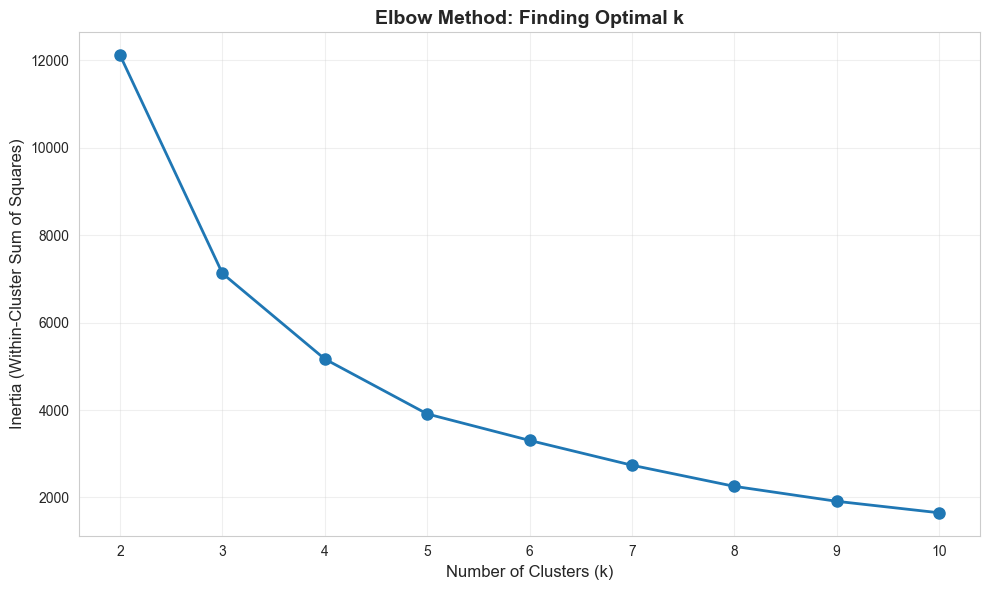

In [51]:
# TODO: Plot the elbow curve
# x-axis: k values
# y-axis: inertia

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method: Finding Optimal k', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Silhouette Score Analysis

Calculate silhouette scores to validate cluster quality

In [52]:
# TODO: Calculate silhouette scores for k from 2 to 10
# For each k:
#   - Train KMeans
#   - Calculate silhouette_score(rfm_scaled, labels)

silhouette_scores = []

# Your code here

for k in k_range:
    # Train k-means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    
    # Calculate silhouette score
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score={score:.4f}")


print("\n" + "="*80)
print("CHECKPOINT: Silhouette Scores Calculated")
print("="*80)

k=2: silhouette score=0.9164
k=3: silhouette score=0.5803
k=4: silhouette score=0.5906
k=5: silhouette score=0.6030
k=6: silhouette score=0.5511
k=7: silhouette score=0.5493
k=8: silhouette score=0.5423
k=9: silhouette score=0.5355
k=10: silhouette score=0.5022

CHECKPOINT: Silhouette Scores Calculated


C:\Users\dddva\AppData\Local\Temp\ipykernel_38852\2874268070.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


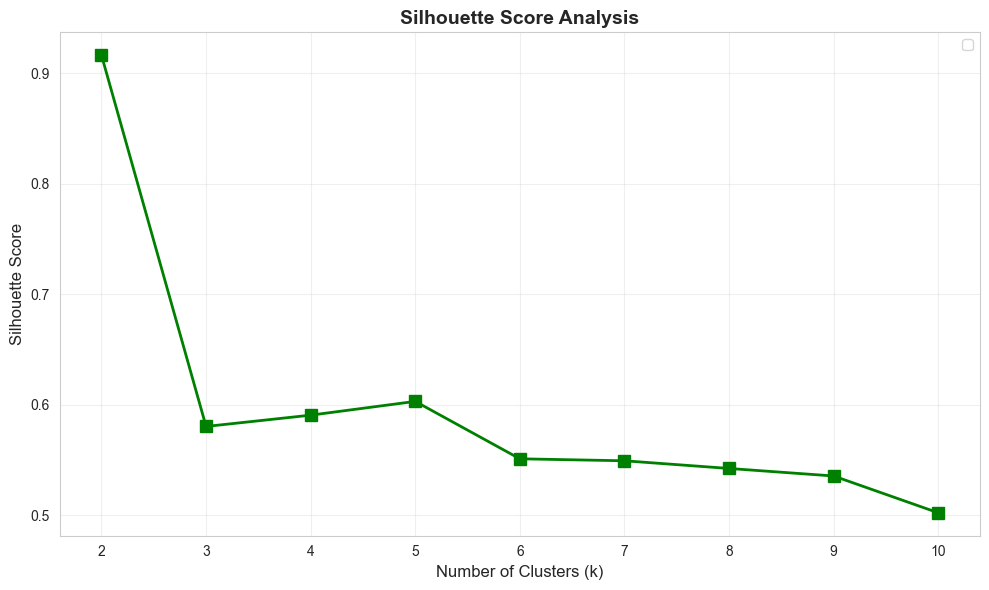

In [53]:
# TODO: Plot silhouette scores
# x-axis: k values
# y-axis: silhouette score

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='s', linewidth=2, markersize=8, color='green')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Select Optimal k

**Your k selection justification (write 2-3 sentences):**

Based on the elbow plot, inertia drops sharply from k = 2 to 3 to 4, but the rate of improvement slows noticeably after k = 4, indicating that this is the elbow point where adding more clusters gives diminishing returns. The silhouette scores support this: while k = 2 has the highest score, it is too simple to capture meaningful structure, and scores for k = 3–5 remain reasonably strong, with k = 5 achieving the best balance (0.6030). For these reasons, k = 5 provides a practical and well‑separated clustering solution without over‑segmenting the data.

In [54]:
# TODO: Set your chosen k value
optimal_k = 5  # Replace with your chosen k (e.g., 4, 5, or 6)

print(f"Chosen k value: {optimal_k}")

Chosen k value: 5


---
## Step 4: Train K-Means Model and Visualize Segments

### Train Final K-Means Model

In [56]:
# TODO: Train KMeans with your optimal_k and random_state=42
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)  # Replace with trained model

# TODO: Add cluster labels to rfm_df
# rfm_df['Cluster'] = ...

rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"\nFinal clustering with k={optimal_k}")
print(f"Cluster sizes:")
print(rfm_df['Cluster'].value_counts().sort_index())


print("\n" + "="*80)
print("CHECKPOINT: K-Means Model Trained")
print(f"Number of clusters: {optimal_k}")
if 'Cluster' in rfm_df.columns:
    print(f"\nCluster sizes:")
    print(rfm_df['Cluster'].value_counts().sort_index())
print("="*80)

cluster_summary = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(f"\nCluster characteristics:")
print(cluster_summary)


Final clustering with k=5
Cluster sizes:
Cluster
0    1920
1    3579
2      24
3     354
4       4
Name: count, dtype: int64

CHECKPOINT: K-Means Model Trained
Number of clusters: 5

Cluster sizes:
Cluster
0    1920
1    3579
2      24
3     354
4       4
Name: count, dtype: int64

Cluster characteristics:
            Recency   Frequency       Monetary
Cluster                                       
0        470.880729    2.164583     754.603699
1         74.981280    5.217100    1953.383557
2         21.833333  119.833333  100927.043417
3         25.579096   29.435028   14502.367551
4          2.750000  212.750000  436835.792500


### Visualize Customer Segments

Create a 2D scatter plot showing Frequency vs Monetary, colored by cluster

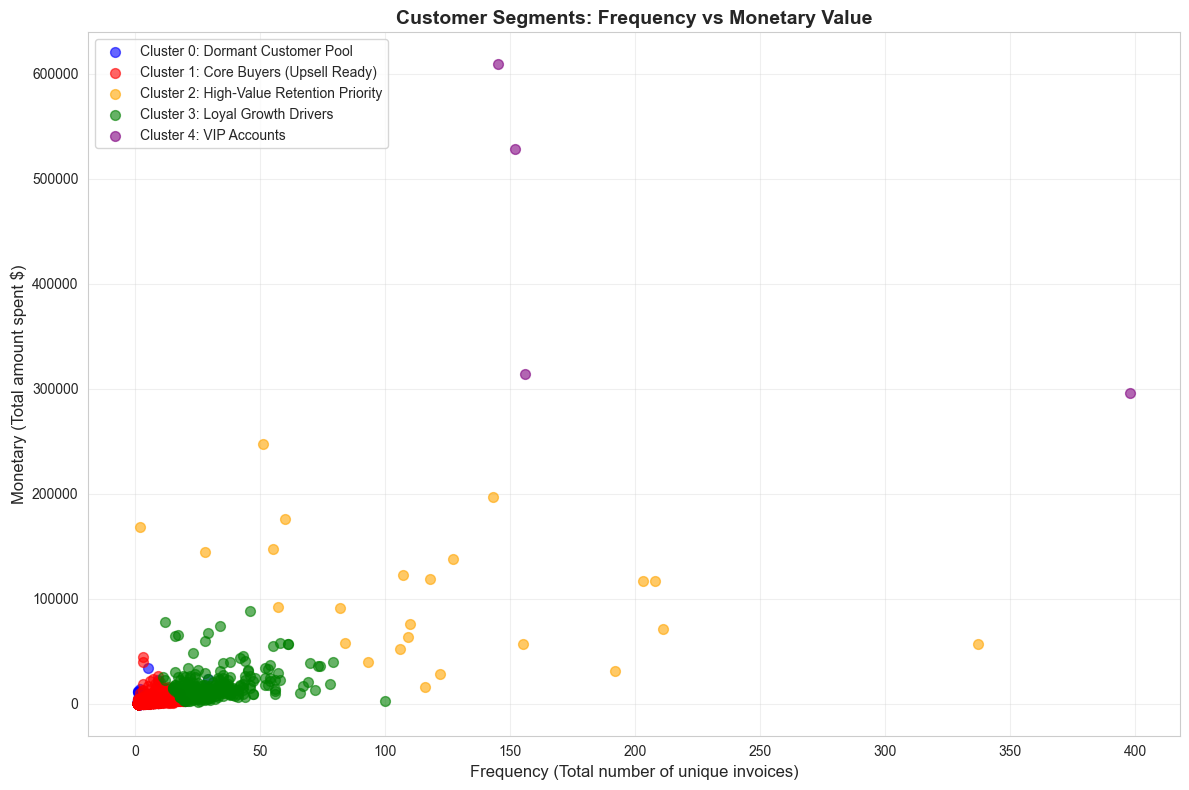

In [72]:
# TODO: Create scatter plot
# x-axis: Frequency
# y-axis: Monetary
# color: Cluster
# Include legend

plt.figure(figsize=(12, 8))

# Define colors for each cluster
colors = {0: 'blue', 1: 'red', 2: 'orange', 3: 'green', 4: 'purple'}
labels = {
    0: 'Cluster 0: Dormant Customer Pool',
    1: 'Cluster 1: Core Buyers (Upsell Ready)',
    2: 'Cluster 2: High-Value Retention Priority',
    3: 'Cluster 3: Loyal Growth Drivers',
    4: 'Cluster 4: VIP Accounts'
}

# Plot each cluster
for cluster in range(5):
    cluster_data = rfm_df[rfm_df['Cluster'] == cluster]
    plt.scatter(
        cluster_data['Frequency'], 
        cluster_data['Monetary'],
        c=colors[cluster],
        label=labels[cluster],
        alpha=0.6,
        s=50
    )

plt.xlabel('Frequency (Total number of unique invoices)', fontsize=12)
plt.ylabel('Monetary (Total amount spent $)', fontsize=12)
plt.title('Customer Segments: Frequency vs Monetary Value', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Calculate Cluster Centers

Show the mean RFM values for each cluster

In [60]:
# TODO: Calculate mean Recency, Frequency, and Monetary for each cluster
cluster_summary = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
# Replace with grouped DataFrame

print("\n" + "="*80)
print("CLUSTER CENTERS (Mean RFM Values)")
print("="*80)
# TODO: Display cluster_summary

print(cluster_summary)


print("="*80)


CLUSTER CENTERS (Mean RFM Values)
            Recency   Frequency       Monetary
Cluster                                       
0        470.880729    2.164583     754.603699
1         74.981280    5.217100    1953.383557
2         21.833333  119.833333  100927.043417
3         25.579096   29.435028   14502.367551
4          2.750000  212.750000  436835.792500


---
## Step 5: Interpret Segments and Provide Business Recommendations

### Segment 0: Dormant Customer Pool

**Customer Profile (3-5 sentences):**

This segment represents a low current-value customer group because its members have the highest recency and the lowest frequency and monetary values among the major clusters. On average, these customers purchased about 471 days ago, made only about 2.16 unique purchases, and spent roughly $754.60, with a median spend of just $379.18. Compared with the other segments, they appear largely inactive: they buy rarely, have not returned in a long time, and contribute relatively little revenue per customer. Their purchasing pattern suggests many are lapsed or one-time buyers, so their business value lies less in immediate profit and more in their potential for re-engagement through win-back campaigns, reminders, or targeted discounts.

In [71]:
# TODO: Calculate detailed statistics for Segment 0
# Show mean, median, min, max for R, F, M
segment_0 = rfm_df[rfm_df['Cluster'] == 0][['Recency', 'Frequency', 'Monetary']].agg(['count','mean', 'median', 'min', 'max'])
print(segment_0)

            Recency    Frequency      Monetary
count   1920.000000  1920.000000   1920.000000
mean     470.880729     2.164583    754.603699
median   434.000000     1.000000    379.180000
min      267.000000     1.000000      0.000000
max      738.000000    29.000000  34095.260000


### Segment 1: Core Buyers (Upsell Ready)

**Customer Profile (3-5 sentences):**

This segment represents the company’s main base of active repeat customers and can be understood as a medium-to-high value group with strong upsell potential. On average, these customers purchased about 75 days ago, made about 5.22 unique purchases, and spent roughly $1,953.38, with median values of 49 days, 4 purchases, and $1,154.47. Compared with the dormant segment, they are much more recent, more engaged, and more profitable, but they are still less valuable than the loyal growth and VIP segments. Their purchasing pattern suggests consistent repeat buying rather than extreme high-end spending, which makes them especially important for cross-selling, bundle offers, and promotions designed to increase order size and purchase frequency.

In [70]:
# TODO: Calculate detailed statistics for Segment 1
segment_1 = rfm_df[rfm_df['Cluster'] == 1][['Recency', 'Frequency', 'Monetary']].agg(['count','mean', 'median', 'min', 'max'])
print(segment_1)

           Recency  Frequency      Monetary
count   3579.00000  3579.0000   3579.000000
mean      74.98128     5.2171   1953.383557
median    49.00000     4.0000   1154.470000
min        0.00000     1.0000      0.000000
max      283.00000    20.0000  44534.300000


### Segment 2: High-Value Retention Priority

**Customer Profile (3-5 sentences):**

This segment consists of extremely valuable customers who combine very high spending with very frequent purchasing and very recent activity. On average, these customers purchased about 21.83 days ago, made about 119.83 unique purchases, and spent roughly $100,927.04, with median values of 3 days, 109.5 purchases, and $91,770.92. Compared with most other segments, they are far more engaged and profitable, although they are still slightly below the tiny VIP cluster in absolute spending intensity. Their business value is exceptionally high because even though there are only 24 customers in this group, they generate a disproportionately large share of revenue, and their purchasing pattern suggests strong loyalty, repeated transactions, and sustained commercial importance.

In [69]:
# TODO: Calculate detailed statistics for Segment 2
segment_2 = rfm_df[rfm_df['Cluster'] == 2][['Recency', 'Frequency', 'Monetary']].agg(['count','mean', 'median', 'min', 'max'])
print(segment_2)

           Recency   Frequency       Monetary
count    24.000000   24.000000      24.000000
mean     21.833333  119.833333  100927.043417
median    3.000000  109.500000   91770.915000
min       0.000000    2.000000   15972.790000
max     372.000000  337.000000  246973.090000


### Segment 3: Loyal Growth Drivers

**Customer Profile (3-5 sentences):**

This segment represents a strong high-value customer group made up of recent, frequent, and consistently profitable buyers. On average, these customers purchased about 25.58 days ago, made about 29.44 unique purchases, and spent roughly $14,502.37, with median values of 9 days, 26 purchases, and $10,504.88. Compared with the core buyer segment, they are far more active and spend much more, but they are still below the high-value retention and VIP segments in overall monetary intensity. Their business value is very high because they combine loyalty with scale, and their purchasing pattern suggests dependable repeat purchasing that can support long-term revenue growth.

In [67]:
# TODO: Calculate detailed statistics for Segment 2
segment_3 = rfm_df[rfm_df['Cluster'] == 3][['Recency', 'Frequency', 'Monetary']].agg(['count', 'mean', 'median', 'min', 'max'])
print(segment_3)

           Recency   Frequency      Monetary
count   354.000000  354.000000    354.000000
mean     25.579096   29.435028  14502.367551
median    9.000000   26.000000  10504.875000
min       0.000000   11.000000   1820.440000
max     497.000000  100.000000  88704.320000


### Segment 4: VIP Accounts

**Customer Profile (3-5 sentences):**

This segment represents the company’s most valuable customers and should be treated as a top-priority strategic group. On average, these customers purchased about 2.75 days ago, made about 212.75 unique purchases, and spent roughly $436,835.79, with median values of 1 day, 154 purchases, and $421,274.45. Compared with every other segment, they are the most recent, the most frequent, and the highest spending customers by a very large margin. Their business value is exceptional because even though there are only 4 customers in this cluster, their purchasing pattern shows extremely strong loyalty, continuous engagement, and an outsized contribution to total revenue.

In [68]:
# TODO: Calculate detailed statistics for Segment 2
segment_4 = rfm_df[rfm_df['Cluster'] == 4][['Recency', 'Frequency', 'Monetary']].agg(['count','mean', 'median', 'min', 'max'])
print(segment_4)

        Recency  Frequency     Monetary
count      4.00       4.00       4.0000
mean       2.75     212.75  436835.7925
median     1.00     154.00  421274.4450
min        0.00     145.00  295972.6300
max        9.00     398.00  608821.6500


---
## Business Recommendations

### Recommendation 1: Reduce Broad Win-Back Spending and Focus on Selectiveness

**Which segment(s) does this target?** Segment 0: Dormant Customer Pool

**Recommendation (3-5 sentences):**

The company should stop using expensive broad win-back campaigns on the entire dormant segment and instead move to a low-cost, highly selective strategy. Since these customers have the highest recency and the lowest frequency and monetary value, many are unlikely to return, so sending repeated promotions to all of them is not an efficient use of budget. The retailer should use low-cost email only, with one limited-time offer or reminder campaign, and then suppress non-responders from future paid reactivation efforts. This will reduce wasted marketing spend and allow the company to redirect money away from low-probability customers toward segments with stronger revenue potential.

### Recommendation 2: Increase Revenue from the Core Customer Base Through Upselling

**Which segment(s) does this target?** Segment 1: Core Buyers (Upsell Ready)

**Recommendation (3-5 sentences):**

The company should treat this segment as its main scalable revenue base and use targeted email campaigns to increase average order value and purchase frequency. These customers are active and profitable, but they are not yet in the highest-value tiers, which means they are strong candidates for bundle offers, product recommendations, and spend-threshold promotions such as free shipping above a certain amount. Messaging could focus on convenience, seasonal suggestions, and “customers also bought” recommendations. This strategy should work well because the group is already engaged and much more likely to respond to relevant offers than inactive customers, making marketing spend more efficient than the current one-size-fits-all approach.

### Recommendation 3: Protect High-Value Customers with VIP Retention and Loyalty Investment

**Which segment(s) does this target?** Segment 2: High-Value Retention Priority, Segment 3: Loyal Growth Drivers, Segment 4: VIP Accounts

**Recommendation (3-5 sentences):**

The company should invest more heavily in retaining its most valuable customers because these segments generate a disproportionately large share of revenue despite representing a small share of the customer base. Instead of generic campaigns, the retailer should use personalized email, loyalty rewards, early access to products, exclusive offers, and where appropriate direct account-style outreach for the VIP group. Messaging should emphasize exclusivity, appreciation, and relationship-building rather than heavy discounting, because these customers are already buying often and spending at very high levels. This approach addresses the marketing director’s concern directly: the business should under-invest less in its best customers and shift resources toward retention strategies where the financial return is likely to be highest.

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - RFM features properly calculated
   - Elbow method and silhouette score visualizations
   - Written justification for your k selection
   - Customer segment scatter plot
   - Descriptive names and profiles for each segment
   - Three specific business recommendations
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed customer segmentation assignment'
git push
```

Submit your GitHub repository link on the course platform.